# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [ ]:
import sys
import gams
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import gdxpds

# Get the absolute path of the Pybalmorel folder
pybalmorel_path = os.path.abspath("/Users/maxfavrot/Balmorel/pybalmorel_MaxF")

# Set the correct path for GAMS
gams_path = "/Library/Frameworks/GAMS.framework/Versions/48/Resources"

# Add Pybalmorel to Python's module search path
if pybalmorel_path not in sys.path:
    sys.path.insert(0, pybalmorel_path)

# Now, you can import your modules
from src.pybalmorel import MainResults
from src.pybalmorel.utils import symbol_to_df

# Set environment variables
os.environ["PATH"] = gams_path + ":" + os.environ.get("PATH", "")
os.environ["DYLD_LIBRARY_PATH"] = gams_path + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")



## Plotter class

In [47]:
class ThesisPlotter:
    def __init__(self,
                 style='whitegrid',
                 palette='Set2',
                 font_scale=1.2,
                 context='notebook',
                 figsize=(10, 6),
                 dpi=100):
        sns.set_theme(style=style, palette=palette, context=context)
        sns.set_context(context, font_scale=font_scale)
        self.figsize = figsize
        self.dpi = dpi
        self.palette = sns.color_palette(palette)

    def barplot(self, df, category_col, value_col, scenario_col,
                title="", unit="", ylabel=None, xlabel=None, legend_title="Scenario",
                save=False):
        """
        Create a barplot comparing scenarios across categories.

        Parameters:
        - df: DataFrame with the input data
        - category_col: column to be used on the x-axis (e.g., "Technology")
        - value_col: column with the values (e.g., "Value")
        - scenario_col: column with different scenarios (used as hue)
        - title: plot title
        - unit: unit displayed on y-axis
        - ylabel: custom y-axis label
        - xlabel: custom x-axis label
        - legend_title: title for the legend
        - save: if true, saves the figure
        """
        plt.figure(figsize=self.figsize, dpi=self.dpi)
        ax = sns.barplot(data=df,
                         x=category_col,
                         y=value_col,
                         hue=scenario_col,
                         palette=self.palette,
                         errorbar=None)

        ax.set_title(title, fontsize=14, weight='bold')
        ax.set_ylabel(ylabel if ylabel else f"{value_col} [{unit}]" if unit else value_col)
        ax.set_xlabel(xlabel if xlabel else category_col)
        ax.legend(title=legend_title)
        plt.xticks()
        plt.tight_layout()

        if save:
            plt.savefig("test.png", dpi=100)
        plt.show()

plotter = ThesisPlotter()


## Working with Outputs

This section presents examples of how to work with the outputs from Balmorel

### MainResults

The main output from Balmorel is MainResults.gdx, which may be loaded from one path (demanding different filenames, e.g., MainResults_SC1.gdx, MainResults_SC2.gdx, etc.) or several paths (which by default gives scenario names of SC1, SC2, ..., SCN format if no list of scenario_names are provided)

In [55]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_LowR_B.gdx', 'MainResults_LowR_HDISC.gdx', 'MainResults_LowR_excel.gdx'], paths='../master_thesis/main_results/MainResults', scenario_names=['SC1', 'SC2', 'SC3'])
res_a = MainResults(files=['all_endofmodel_LowR_B.gdx', 'all_endofmodel_LowR_HDISC.gdx', 'all_endofmodel_LowR_excel.gdx'], paths='../master_thesis/main_results/all_endofmodel', scenario_names=['SC1', 'SC2', 'SC3'])


/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_LowR_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_LowR_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_LowR_excel.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_excel.gdx


In [ ]:
### 1.1.3 Plotting bar charts with an interactive gui
res.interactive_bar_chart()

Result type: balmorel


GridBox(children=(Dropdown(description='Table:', layout=Layout(width='80%'), options=('F_CONS_YCRA', 'F_CONS_Y…

Output()

Stack(children=(GridBox(children=(SelectMultiple(description='Scenario', index=(0,), layout=Layout(height='99%…

Output()

Output()

HBox()

Output()

Output()

Output()

# Sense check: Total costs of the system
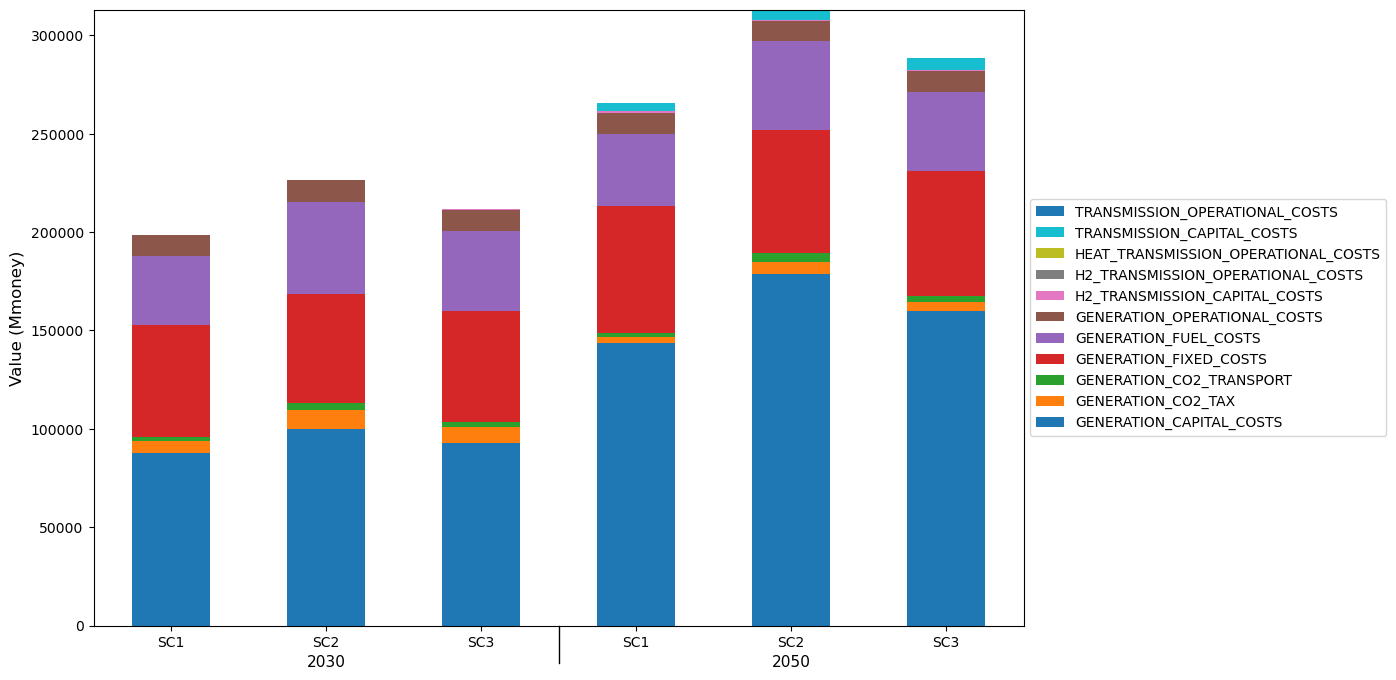

# GENERATION MIX
## Main Idea: There will be more renewable energy sources (RES) with a lower discount rate (DR)
Arguments:
- RES like wind and solar are Capital Expenditures (CAPEX)-intensive with low Operating Expenditures (OPEX), so most of the negative cashflows occur in the beginning in the project (with a high present value), and most of the positive cashflows (liked to revenues) occur later in time, so more subject to discounting. 
- A lower DR makes upfront investments more attractive, improving project economics for RES. 
- A higher DR penalizes long-term returns, making fossil plants with lower CAPEX and shorter payback periods more competitive.

As a result, higher DR favours gas/coal, while lower DR accelerates RES deployment.

"The most influential parameters for Renewable Energy Production is the discount rate" according to N. Moksnes & W. Usher in The relative importance of uncertain parameters and structural formulation for electricity systems planning in Kenya and Benin




In [45]:
prod_cap = res.get_result('G_CAP_YCRAF')
#prod_cap

In [102]:
prod_cap

,Scenario,Year,Country,Region,Area,Generation,Fuel,Commodity,Technology,Category,Unit,Value
0,SC1,2030,NORWAY,NO1,NO1_A1,GNR_RES_WTR_NOPMP_MC-01,WATER,ELECTRICITY,HYDRO-RESERVOIRS,EXOGENOUS,GW,0.160000
1,SC1,2030,NORWAY,NO1,NO1_A1,GNR_RES_WTR_NOPMP_MC-02,WATER,ELECTRICITY,HYDRO-RESERVOIRS,EXOGENOUS,GW,0.160000
2,SC1,2030,NORWAY,NO1,NO1_A1,GNR_RES_WTR_NOPMP_MC-03,WATER,ELECTRICITY,HYDRO-RESERVOIRS,EXOGENOUS,GW,0.160000
3,SC1,2030,NORWAY,NO1,NO1_A1,GNR_RES_WTR_NOPMP_MC-04,WATER,ELECTRICITY,HYDRO-RESERVOIRS,EXOGENOUS,GW,0.160000
4,SC1,2030,NORWAY,NO1,NO1_A1,GNR_RES_WTR_NOPMP_MC-05,WATER,ELECTRICITY,HYDRO-RESERVOIRS,EXOGENOUS,GW,0.160000
...,...,...,...,...,...,...,...,...,...,...,...,...
48833,SC3,2050,CYPRUS,CY,CY_IDVU-HOTWTR,GNR_HP_ELEC_AIR-WTR_COP-325_SS-4-KW,ELECTRIC,HEAT,ELECT-TO-HEAT,DECOMMISSIONING,GW,-0.004744
48834,SC3,2050,CYPRUS,CY,CY_IDVU-HOTWTR,GNR_HP_ELEC_GROUND-WTR_COP-400_SS-10-KW_Y-2050,ELECTRIC,HEAT,ELECT-TO-HEAT,ENDOGENOUS,GW,0.220628
48835,SC3,2050,CYPRUS,CY,CY_IDVU-HOTWTR,GNR_HS_HEAT_WTR-TANK_SS_E-95_Y-2010,HEAT,HEAT,INTRASEASONAL-HEAT-STORAGE,EXOGENOUS,GW,1.861753
48836,SC3,2050,CYPRUS,CY,CY_IDVU-HOTWTR,GNR_HS_HEAT_WTR-TANK_SS_E-95_Y-2010,HEAT,HEAT,INTRASEASONAL-HEAT-STORAGE,DECOMMISSIONING,GW,-1.861753


/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_15781/725748048.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Scenario'] = df['Scenario'].replace({
/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_15781/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(data=df,


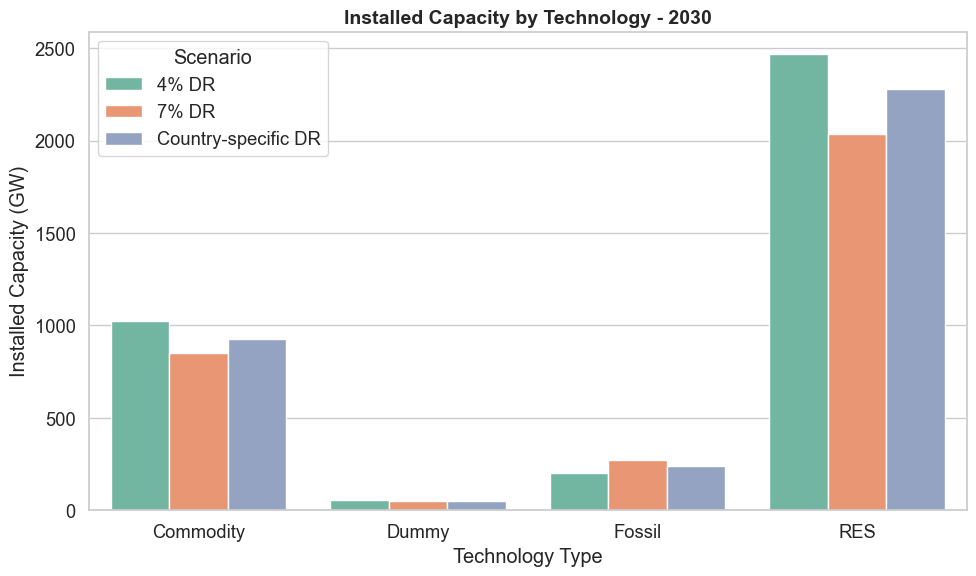

,Year,Scenario,Type,Value
0,2030,4% DR,Commodity,1025.691148
1,2030,4% DR,Dummy,53.005934
2,2030,4% DR,Fossil,201.477198
3,2030,4% DR,RES,2466.818672
4,2030,7% DR,Commodity,851.199689
5,2030,7% DR,Dummy,49.342891
6,2030,7% DR,Fossil,274.375407
7,2030,7% DR,RES,2035.378694
8,2030,Country-specific DR,Commodity,925.729622
9,2030,Country-specific DR,Dummy,51.712407


In [113]:
df = prod_cap.copy()

# --- CLASSIFY FUEL TYPES ---
res_fuels = ['SUN', 'WATER', 'WIND', 'WOOD', 'WOODCHIPS', 'WOODPELLETS', 'WOODWASTE']
commodity_fuels = ['ELECTRIC', 'HEAT', 'HYDROGEN']
dummy_fuels = ['DUMMY', 'IMPORT_H2', 'MUNIWASTE', 'WASTEHEAT']

df['Type'] = 'Fossil'  # Default
df.loc[prod_cap['Fuel'].isin(res_fuels), 'Type'] = 'RES'
df.loc[prod_cap['Fuel'].isin(commodity_fuels), 'Type'] = 'Commodity'
df.loc[prod_cap['Fuel'].isin(dummy_fuels), 'Type'] = 'Dummy'

# sum the values of unique combinaisons of year, scenario, type
df = df.groupby(['Year', 'Scenario', 'Type']).agg({'Value': 'sum'}).reset_index()
df1 = df
#filter only 2030
df = df[df['Year'] == '2030']

# Filter out commodities and dummy fuels
#df = df[~df['Type'].isin(['Commodity', 'Dummy'])]


# --- RELABEL & CLEAN ---
df['Scenario'] = df['Scenario'].replace({
    'SC1': '4% DR',
    'SC2': '7% DR',
    'SC3': 'Country-specific DR'
})




# --- PLOT ---
plotter.barplot(df,
                category_col='Type',
                value_col='Value',
                scenario_col='Scenario',
                title="Installed Capacity by Technology - 2030",
                unit='GW',
                ylabel="Installed Capacity (GW)",
                xlabel="Technology Type",
                save=True)
df

In [108]:
df1

,Year,Scenario,Type,Value
0,2030,SC1,Commodity,1025.691148
1,2030,SC1,Dummy,53.005934
2,2030,SC1,Fossil,201.477198
3,2030,SC1,RES,2466.818672
4,2030,SC2,Commodity,851.199689
5,2030,SC2,Dummy,49.342891
6,2030,SC2,Fossil,274.375407
7,2030,SC2,RES,2035.378694
8,2030,SC3,Commodity,925.729622
9,2030,SC3,Dummy,51.712407


### RES are CAPEX intensive and have lower OPEX

In [ ]:
costs = res_a.get_result('GDATA')
df = costs.copy()
CAPEX = df[df['GDATASET'] == 'GDINVCOST0']
CAPEX = CAPEX.drop(columns=['Scenario', 'GDATASET'])
CAPEX = CAPEX.reset_index(drop=True)
CAPEX = CAPEX.rename(columns={'Value': 'CAPEX'})
#CAPEX

,GGG,CAPEX
0,AUVERE_ST_SHALE_CND,1.380000
1,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2020,2.118909
2,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2030,1.807403
3,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2040,1.685624
4,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2050,1.653937
...,...,...
2428,GNR_BIOGASUPGRADING_E-100_Y-2050,0.336140
2429,GNR_BIOGASMETHANATION_E-168_Y-2020,0.889056
2430,GNR_BIOGASMETHANATION_E-168_Y-2030,0.740880
2431,GNR_BIOGASMETHANATION_E-168_Y-2040,0.592704


In [72]:
costs = res_a.get_result('GDATA')
df = costs.copy()
OPEX = df[df['GDATASET'] == 'GDOMFCOST0']
OPEX = OPEX.drop(columns=['Scenario', 'GDATASET'])
OPEX = OPEX.reset_index(drop=True)
OPEX = OPEX.rename(columns={'Value': 'OPEX'})
OPEX

,GGG,OPEX
0,ACHEMA1_ST_NGAS_EXT,12.050668
1,ACHEMA2_ST_NGAS_EXT,12.050668
2,ADAM-1_ST_LIGNITE_EXT,56.056000
3,ADAM-2_ST_LIGNITE_CON,56.056000
4,AGG-DE4-E_ES_ELEC,0.370644
...,...,...
4543,GNR_BIOGASUPGRADING_E-100_Y-2050,8.428000
4544,GNR_BIOGASMETHANATION_E-168_Y-2020,35.562240
4545,GNR_BIOGASMETHANATION_E-168_Y-2030,29.635200
4546,GNR_BIOGASMETHANATION_E-168_Y-2040,23.708160


In [73]:
costs = res_a.get_result('GDATA')
df = costs.copy()
LT = df[df['GDATASET'] == 'GDLIFETIME']
LT = LT.drop(columns=['Scenario', 'GDATASET'])
LT = LT.reset_index(drop=True)
LT = LT.rename(columns={'Value': 'LifeTime'})
LT

,GGG,LifeTime
0,ACHEMA1_ST_NGAS_EXT,20.0
1,ACHEMA2_ST_NGAS_EXT,20.0
2,ALYTUS_ENG_NGAS_BP,20.0
3,AUVERE_ST_SHALE_CND,30.0
4,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2020,27.0
...,...,...
2566,GNR_BIOGASMETHANATION_E-168_Y-2030,25.0
2567,GNR_BIOGASMETHANATION_E-168_Y-2040,25.0
2568,GNR_BIOGASMETHANATION_E-168_Y-2050,25.0
2569,GNR_BACKUP_HYDROGEN,25.0


In [89]:
# Load the GDX file
all = gdxpds.to_dataframes('../master_thesis/main_results/all_endofmodel/all_endofmodel_LowR_B.gdx')

In [96]:
gdata = all['GDATA'].copy()

#Create a new DataFrame with the columns CAPEX, OPEX, and LifeTime
CAPEX = gdata[gdata['GDATASET'] == 'GDINVCOST0']
CAPEX = CAPEX.reset_index(drop=True)
CAPEX = CAPEX.rename(columns={'Value': 'CAPEX'})
OPEX = gdata[gdata['GDATASET'] == 'GDOMFCOST0']
OPEX = OPEX.reset_index(drop=True)
OPEX = OPEX.rename(columns={'Value': 'OPEX'})
LT = gdata[gdata['GDATASET'] == 'GDLIFETIME']
LT = LT.reset_index(drop=True)
LT = LT.rename(columns={'Value': 'LifeTime'})
FUEL = gdata[gdata['GDATASET'] == 'GDFUEL']
FUEL = FUEL.reset_index(drop=True)
FUEL = FUEL.rename(columns={'Value': 'FUEL'})
# Merge the DataFrames on the GGG column
merged_df = pd.merge(CAPEX, OPEX, on=['GGG'])
merged_df.drop(columns=['GDATASET_x', 'GDATASET_y'], inplace=True)
merged_df = pd.merge(merged_df, LT, on=['GGG'])
merged_df = pd.merge(merged_df, FUEL, on=['GGG'])
merged_df.drop(columns=['GDATASET_x', 'GDATASET_y'], inplace=True)
merged_df

,GGG,CAPEX,OPEX,LifeTime,FUEL
0,AUVERE_ST_SHALE_CND,1.380000,30.00000,30.0,4.130000e+303
1,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2020,2.118909,48.02000,27.0,4.280000e+303
2,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2030,1.807403,37.45560,30.0,4.280000e+303
3,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2040,1.685624,32.65360,30.0,4.280000e+303
4,BE-OFF1_WT_WIND_OFF_L-RG2_Y-2050,1.653937,31.69320,30.0,4.280000e+303
...,...,...,...,...,...
798,GNR_BIOGASUPGRADING_E-100_Y-2050,0.336140,8.42800,15.0,4.250000e+303
799,GNR_BIOGASMETHANATION_E-168_Y-2020,0.889056,35.56224,25.0,4.250000e+303
800,GNR_BIOGASMETHANATION_E-168_Y-2030,0.740880,29.63520,25.0,4.250000e+303
801,GNR_BIOGASMETHANATION_E-168_Y-2040,0.592704,23.70816,25.0,4.250000e+303


In [101]:

# change the type of FUEL column to string
FUEL['FUEL'] = FUEL['FUEL'].astype(str)
FUEL

,GGG,GDATASET,FUEL
0,ACHEMA1_ST_NGAS_EXT,GDFUEL,4.06e+303
1,ACHEMA2_ST_NGAS_EXT,GDFUEL,4.06e+303
2,ADAM-1_ST_LIGNITE_EXT,GDFUEL,4.08e+303
3,ADAM-2_ST_LIGNITE_CON,GDFUEL,4.08e+303
4,AGG-DE4-E_ES_ELEC,GDFUEL,4.31e+303
...,...,...,...
1520,GNR_BIOGASMETHANATION_E-168_Y-2030,GDFUEL,4.25e+303
1521,GNR_BIOGASMETHANATION_E-168_Y-2040,GDFUEL,4.25e+303
1522,GNR_BIOGASMETHANATION_E-168_Y-2050,GDFUEL,4.25e+303
1523,GNR_BACKUP_HYDROGEN,GDFUEL,4.31e+303


### Endogenous capacities

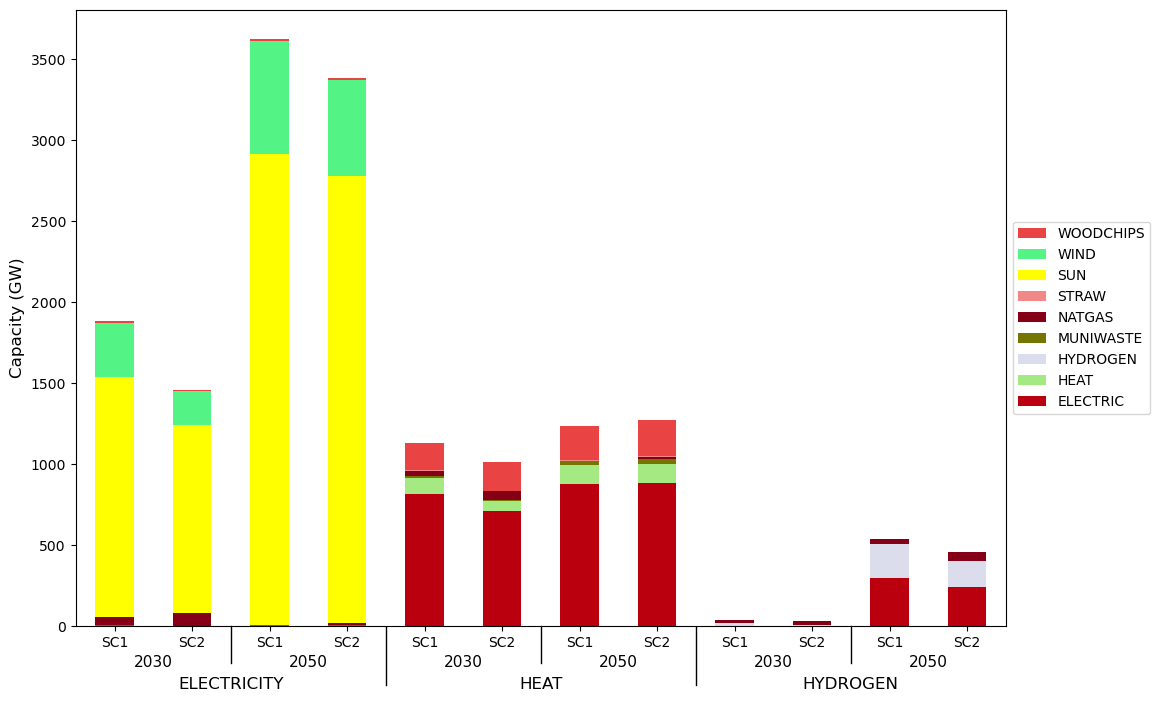

# Electricity prices

In [107]:
el_price = res.get_result('EL_PRICE_YCRST')
#el_price 

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_64300/2640490894.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


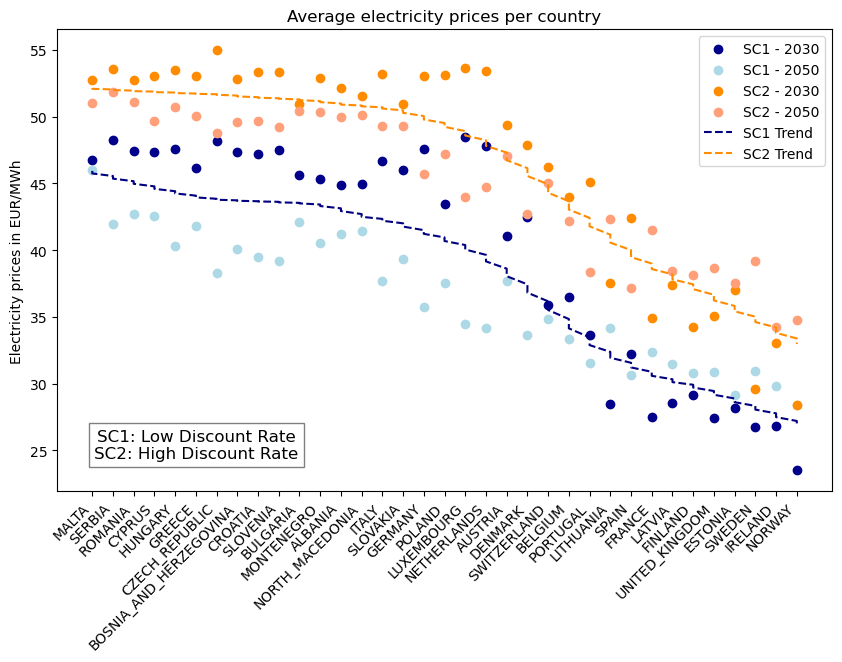

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Compute average price per country
countrylist = el_price.groupby('Country')['Value'].mean().sort_values(ascending=False).index.tolist()

# Compute average values per scenario, country, and year
el_price_avg = el_price.groupby(['Scenario', 'Country', 'Year']).mean(numeric_only=True).reset_index()

# Sort the countries in el_price_avg according to countrylist
el_price_avg['Country'] = pd.Categorical(el_price_avg['Country'], categories=countrylist, ordered=True)
el_price_avg = el_price_avg.sort_values('Country')

# Define color mapping (Year as string)
colors = {
    ('SC1', '2030'): 'darkblue',
    ('SC1', '2050'): 'lightblue',
    ('SC2', '2030'): 'darkorange',
    ('SC2', '2050'): 'lightsalmon'
}

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over groups to plot
for (scenario, year), group in el_price_avg.groupby(['Scenario', 'Year']):
    ax.scatter(group['Country'], group['Value'], 
               color=colors[(scenario, year)], 
               label=f"{scenario} - {year}")

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add y-axis label
ax.set_ylabel("Electricity prices in EUR/MWh")

# Add title
ax.set_title("Average electricity prices per country")

# Add smooth trendlines using LOWESS
for scenario in ['SC1', 'SC2']:
    subset = el_price_avg[el_price_avg['Scenario'] == scenario]
    if not subset.empty:
        x_numeric = np.arange(len(subset))
        smoothed = lowess(subset['Value'], x_numeric, frac=0.3)  # frac=0.3 controls smoothness
        ax.plot(subset['Country'], smoothed[:, 1], 
                color='navy' if scenario == 'SC1' else 'darkorange', 
                linestyle='--', label=f"{scenario} Trend")

# Add legend
ax.legend()

# Add a text box with the SC1: Low Discount Rate and SC2: High Discount Rate
ax.text(0.18, 0.1, 'SC1: Low Discount Rate\nSC2: High Discount Rate', 
        horizontalalignment='center', verticalalignment='center', 
        transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Show plot
plt.show()


In [109]:
# Give the average price per scenario and the % difference between the two scenarios
avg_sc1 = el_price_avg[el_price_avg['Scenario'] == 'SC1']['Value'].mean()
avg_sc2 = el_price_avg[el_price_avg['Scenario'] == 'SC2']['Value'].mean()
differece = avg_sc2 - avg_sc1
percentage = differece / avg_sc1 * 100
print(f"Average price for SC1: {avg_sc1:.2f} EUR/MWh")
print(f"Average price for SC2: {avg_sc2:.2f} EUR/MWh")
print(f"Percentage difference: {percentage:.2f}%")

Average price for SC1: 38.27 EUR/MWh
Average price for SC2: 46.00 EUR/MWh
Percentage difference: 20.20%


# CO2 Emissions

In [126]:
emi = res.get_result('EMI_YCRAG')
#emi

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_64300/2976474354.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


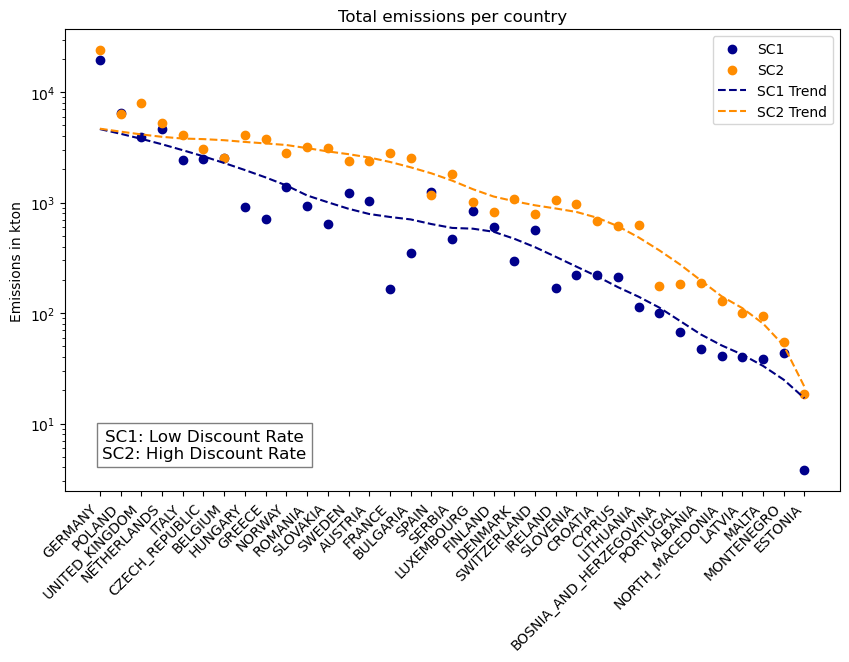

In [ ]:
# Compute sum price per country
countrylist = emi.groupby('C')['Value'].sum().sort_values(ascending=False).index.tolist()

# Compute sum values per scenario, country, and year
emi_avg = emi.groupby(['Scenario', 'C']).sum(numeric_only=True).reset_index()

# Sort the countries in emi_avg according to countrylist
emi_avg['C'] = pd.Categorical(emi_avg['C'], categories=countrylist, ordered=True)
emi_avg = emi_avg.sort_values('C')

# Define color mapping
colors = {
    'SC1': 'darkblue',
    'SC2': 'darkorange'
}

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

# Iterate over groups to plot
for scenario, group in emi_avg.groupby('Scenario'):
    scenario_name = scenario if isinstance(scenario, str) else scenario[0]
    ax.scatter(group['C'], group['Value'], 
               color=colors[scenario_name], 
               label=f"{scenario_name}")

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add y-axis label
ax.set_ylabel("Emissions in kton")

# Set the y-axis to a log scale
ax.set_yscale('log')

# Add title
ax.set_title("Total emissions per country")

# Add smooth trendlines using LOWESS
for scenario in ['SC1', 'SC2']:
    subset = emi_avg[emi_avg['Scenario'] == scenario]
    if not subset.empty:
        x_numeric = np.arange(len(subset))
        smoothed = lowess(subset['Value'], x_numeric, frac=0.3)  # frac=0.3 controls smoothness
        ax.plot(subset['C'], smoothed[:, 1], 
                color='navy' if scenario == 'SC1' else 'darkorange', 
                linestyle='--', label=f"{scenario} Trend")

# Add legend
ax.legend()

# Add a text box with SC1 and SC2 labels for better understanding
ax.text(0.18, 0.1, 'SC1: Low Discount Rate\nSC2: High Discount Rate', 
        horizontalalignment='center', verticalalignment='center', 
        transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Show plot
plt.show()


In [127]:
# Give the average emissions per scenario and the % difference between the two scenarios
avg_sc1 = emi_avg[emi_avg['Scenario'] == 'SC1']['Value'].mean()
avg_sc2 = emi_avg[emi_avg['Scenario'] == 'SC2']['Value'].mean()
differece = avg_sc2 - avg_sc1
percentage = differece / avg_sc1 * 100
print(f"Average emissions for SC1: {avg_sc1:.2f} kton")
print(f"Average emissions for SC2: {avg_sc2:.2f} kton")
print(f"Percentage difference: {percentage:.2f}%")

Average emissions for SC1: 1566.02 kton
Average emissions for SC2: 2628.01 kton
Percentage difference: 67.81%


# Transmission capacities

Found MainResults in Balmorel_MaxF/master_thesis/main_results/MainResults_LowR_B.gdx


/Users/maxfavrot/Balmorel/pybalmorel_MaxF/src/pybalmorel/plotting/maps_balmorel.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_line_new = pd.concat([df_line_new, df_line.loc[[k]]], ignore_index=True)


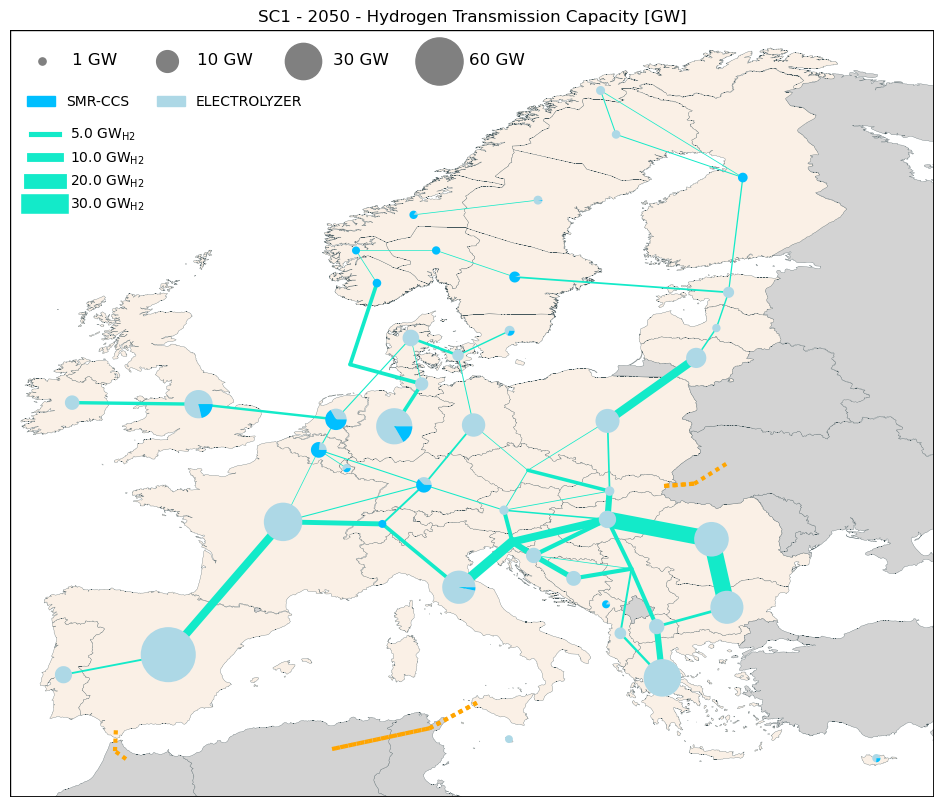

In [17]:
### 1.1.5 Plotting map of transmission capacity
fig, ax = res.plot_map(scenario='SC1', year=2050, commodity='Hydrogen', lines='Capacity', generation='Capacity')

Found MainResults in Balmorel_MaxF/master_thesis/main_results/MainResults_LowR_HDISC.gdx


/Users/maxfavrot/Balmorel/pybalmorel_MaxF/src/pybalmorel/plotting/maps_balmorel.py:730: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_line_new = pd.concat([df_line_new, df_line.loc[[k]]], ignore_index=True)


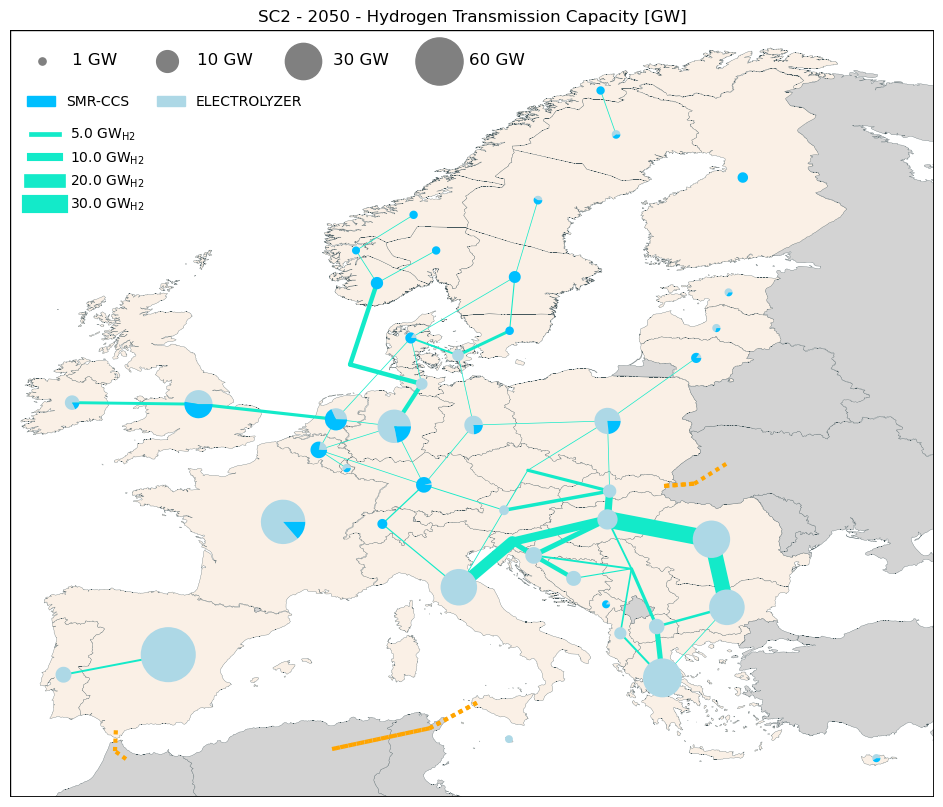

In [ ]:
### 1.1.5 Plotting map of transmission capacity
fig, ax = res.plot_map(scenario='SC2', year=2050, commodity='Hydrogen', lines='Capacity', generation='Capacity')

# Country Specific Scenario

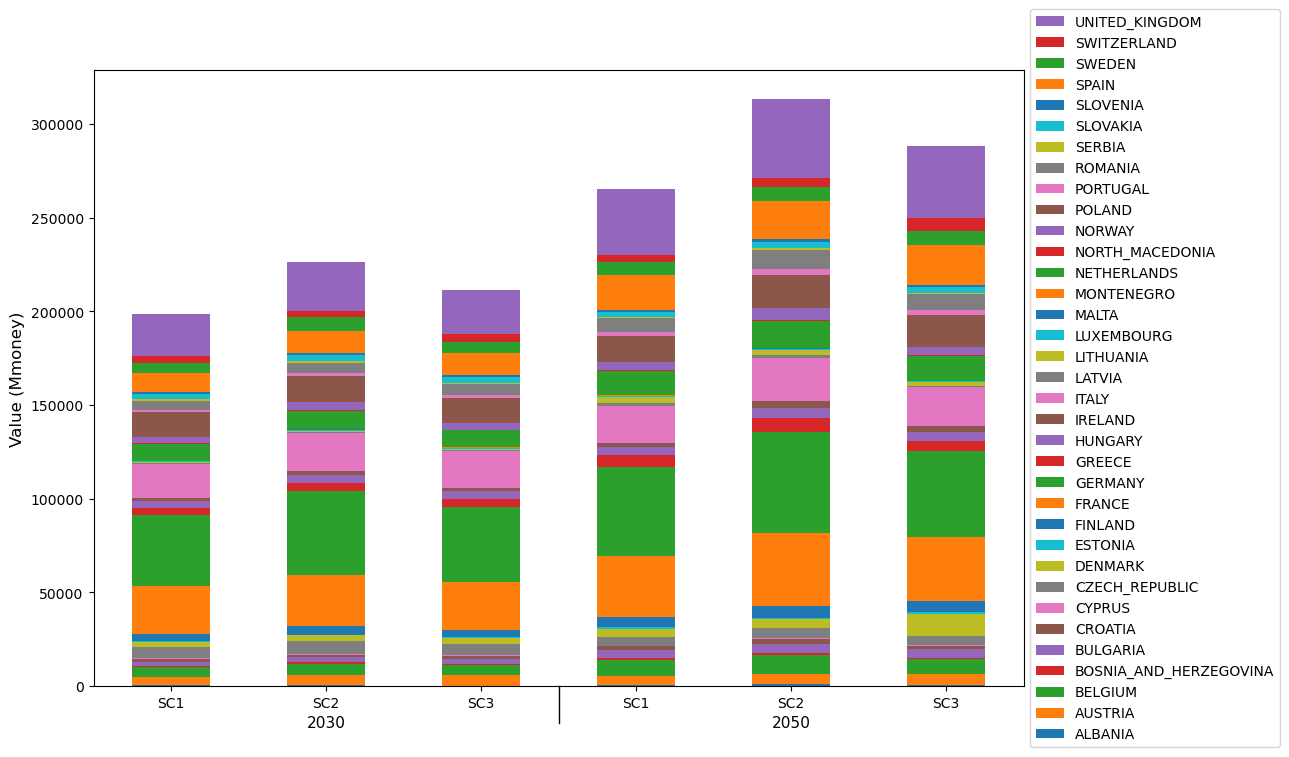

### Other General Functions

In [29]:
### Using symbol_to_df

ws = gams.GamsWorkspace()
db = ws.add_database_from_gdx(os.path.abspath('Balmorel_MaxF/master_thesis/main_results/MainResults_LowR_B.gdx'))

H2_price = symbol_to_df(db, 'H2_PRICE_YCR')
H2_price        

,Year,Country,Region,Category,Unit,Value
0,2030,NORWAY,NO1,AVERAGE,Money_per_MWh,41.846659
1,2030,NORWAY,NO2,AVERAGE,Money_per_MWh,41.819422
2,2030,NORWAY,NO3,AVERAGE,Money_per_MWh,41.798326
3,2030,NORWAY,NO4,AVERAGE,Money_per_MWh,40.118888
4,2030,NORWAY,NO5,AVERAGE,Money_per_MWh,41.814206
...,...,...,...,...,...,...
87,2050,NORTH_MACEDONIA,MK,AVERAGE,Money_per_MWh,40.393527
88,2050,BOSNIA_AND_HERZEGOVINA,BA,AVERAGE,Money_per_MWh,41.540704
89,2050,SERBIA,RS,AVERAGE,Money_per_MWh,41.078101
90,2050,MALTA,MT,AVERAGE,Money_per_MWh,43.754580
